# This is going to be the data analyze the Crime Scene in 2020-2024

### Outcome

Which group of Age, Sex seems to be impacted the most by the crime.

    - How often does the crime commited.

    - What area is risky for the type of the age and sex to live in.

    - What time should they avoid to be in the street
    

### Data Cleaning

In [91]:
### Library imported
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import HTML, display
import statsmodels.api as sm
import statsmodels.formula.api as smf
display(HTML(gt_table.as_raw_html()))


df_raw = pd.read_csv("Crime_Data_from_2020_to_2024.csv")




- **DR_NO**: Division of Records Number - Official file number (2-digit year + area ID + 5 digits).
- **Date Rptd**: Date the crime was reported (MM/DD/YYYY).
- **DATE OCC**: Date the crime occurred (MM/DD/YYYY).
- **TIME OCC**: Time the crime occurred (24-hour military format).
- **AREA**: LAPD Geographic Area code (1-21, representing police stations).
- **AREA NAME**: Name of the Geographic Area (e.g., "77th Street Division").
- **Rpt Dist No**: Four-digit Reporting District code within the area.
- **Part 1-2**: Crime classification (1 for Part I crimes like violent offenses, 2 for Part II).
- **Crm Cd**: Crime code number (indicates the type of crime).
- **Crm Cd Desc**: Description of the crime code.
- **Mocodes** (likely in ...): Modus Operandi codes (activities associated with the suspect).
- **Vict Age** (likely in ...): Victim's age (2-character numeric).
- **Vict Sex** (likely in ...): Victim's sex (F=Female, M=Male, X=Unknown).
- **Vict Descent** (likely in ...): Victim's descent code (e.g., H=Hispanic, W=White, B=Black).
- **Premis Cd** (likely in ...): Code for the location type where the crime occurred.
- **Status**: Case status code.
- **Status Desc**: Description of the case status.
- **Crm Cd 1-4**: Additional crime codes (up to 4 per incident).
- **LOCATION**: Address or location description of the crime.
- **Cross Street**: Nearest cross street.
- **LAT**: Latitude coordinate.
- **LON**: Longitude coordinate.

In [77]:
df_raw.head()




,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,211507896,04/11/2021 12:00:00 AM,11/07/2020 12:00:00 AM,845,15,N Hollywood,1502,2,354,THEFT OF IDENTITY,...,IC,Invest Cont,354.0,NaN,NaN,NaN,7800 BEEMAN AV,NaN,34.2124,-118.4092
1,201516622,10/21/2020 12:00:00 AM,10/18/2020 12:00:00 AM,1845,15,N Hollywood,1521,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",...,IC,Invest Cont,230.0,NaN,NaN,NaN,ATOLL AV,N GAULT,34.1993,-118.4203
2,240913563,12/10/2024 12:00:00 AM,10/30/2020 12:00:00 AM,1240,9,Van Nuys,933,2,354,THEFT OF IDENTITY,...,IC,Invest Cont,354.0,NaN,NaN,NaN,14600 SYLVAN ST,NaN,34.1847,-118.4509
3,210704711,12/24/2020 12:00:00 AM,12/24/2020 12:00:00 AM,1310,7,Wilshire,782,1,331,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,...,IC,Invest Cont,331.0,NaN,NaN,NaN,6000 COMEY AV,NaN,34.0339,-118.3747
4,201418201,10/03/2020 12:00:00 AM,09/29/2020 12:00:00 AM,1830,14,Pacific,1454,1,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),...,IC,Invest Cont,420.0,NaN,NaN,NaN,4700 LA VILLA MARINA,NaN,33.9813,-118.4350


In [78]:
df_raw.describe()

,DR_NO,TIME OCC,AREA,Rpt Dist No,Part 1-2,Crm Cd,Vict Age,Premis Cd,Weapon Used Cd,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LAT,LON
count,1.004894e+06,1.004894e+06,1.004894e+06,1.004894e+06,1.004894e+06,1.004894e+06,1.004894e+06,1.004878e+06,327216.000000,1.004883e+06,69154.000000,2314.000000,64.00000,1.004894e+06,1.004894e+06
mean,2.202190e+08,1.339901e+03,1.069153e+01,1.115613e+03,1.400313e+00,5.001386e+02,2.891862e+01,3.056108e+02,363.950797,4.998992e+02,958.097796,984.015990,991.21875,3.399820e+01,-1.180908e+02
std,1.319070e+07,6.510761e+02,6.110248e+00,6.111596e+02,4.899620e-01,2.052638e+02,2.199267e+01,2.192913e+02,123.737665,2.050643e+02,110.358509,52.350982,27.06985,1.610789e+00,5.582654e+00
min,8.170000e+02,1.000000e+00,1.000000e+00,1.010000e+02,1.000000e+00,1.100000e+02,-4.000000e+00,1.010000e+02,101.000000,1.100000e+02,210.000000,310.000000,821.00000,0.000000e+00,-1.186676e+02
25%,2.106168e+08,9.000000e+02,5.000000e+00,5.870000e+02,1.000000e+00,3.310000e+02,0.000000e+00,1.010000e+02,311.000000,3.310000e+02,998.000000,998.000000,998.00000,3.401470e+01,-1.184305e+02
50%,2.209158e+08,1.420000e+03,1.100000e+01,1.139000e+03,1.000000e+00,4.420000e+02,3.000000e+01,2.030000e+02,400.000000,4.420000e+02,998.000000,998.000000,998.00000,3.405890e+01,-1.183225e+02
75%,2.311102e+08,1.900000e+03,1.600000e+01,1.613000e+03,2.000000e+00,6.260000e+02,4.400000e+01,5.010000e+02,400.000000,6.260000e+02,998.000000,998.000000,998.00000,3.416490e+01,-1.182739e+02
max,2.521040e+08,2.359000e+03,2.100000e+01,2.199000e+03,2.000000e+00,9.560000e+02,1.200000e+02,9.760000e+02,516.000000,9.560000e+02,999.000000,999.000000,999.00000,3.433430e+01,0.000000e+00


In [79]:
### rename the column

df = df_raw.rename(columns={
    'DR_NO': 'dr_no',
    'Date Rptd': 'date_reported',
    'DATE OCC': 'date_occurred',
    'TIME OCC': 'time_occurred',
    'AREA': 'area',
    'AREA NAME': 'area_name',
    'Rpt Dist No': 'reporting_district',
    'Part 1-2': 'part_1_2',
    'Crm Cd': 'crime_code',
    'Crm Cd Desc': 'crime_description',
    'Vict Age': 'vict_age',
    'Vict Sex': 'vict_sex',
    'Status': 'status',
    'Status Desc': 'status_description',
    'Crm Cd 1': 'crime_code_1',
    'Crm Cd 2': 'crime_code_2',
    'Crm Cd 3': 'crime_code_3',
    'Crm Cd 4': 'crime_code_4',
    'LOCATION': 'location',
    'Cross Street': 'cross_street',
    'LAT': 'latitude',
    'LON': 'longitude'
    # Add more columns as needed
})
df.head()

,dr_no,date_reported,date_occurred,time_occurred,area,area_name,reporting_district,part_1_2,crime_code,crime_description,...,status,status_description,crime_code_1,crime_code_2,crime_code_3,crime_code_4,location,cross_street,latitude,longitude
0,211507896,04/11/2021 12:00:00 AM,11/07/2020 12:00:00 AM,845,15,N Hollywood,1502,2,354,THEFT OF IDENTITY,...,IC,Invest Cont,354.0,NaN,NaN,NaN,7800 BEEMAN AV,NaN,34.2124,-118.4092
1,201516622,10/21/2020 12:00:00 AM,10/18/2020 12:00:00 AM,1845,15,N Hollywood,1521,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",...,IC,Invest Cont,230.0,NaN,NaN,NaN,ATOLL AV,N GAULT,34.1993,-118.4203
2,240913563,12/10/2024 12:00:00 AM,10/30/2020 12:00:00 AM,1240,9,Van Nuys,933,2,354,THEFT OF IDENTITY,...,IC,Invest Cont,354.0,NaN,NaN,NaN,14600 SYLVAN ST,NaN,34.1847,-118.4509
3,210704711,12/24/2020 12:00:00 AM,12/24/2020 12:00:00 AM,1310,7,Wilshire,782,1,331,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,...,IC,Invest Cont,331.0,NaN,NaN,NaN,6000 COMEY AV,NaN,34.0339,-118.3747
4,201418201,10/03/2020 12:00:00 AM,09/29/2020 12:00:00 AM,1830,14,Pacific,1454,1,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),...,IC,Invest Cont,420.0,NaN,NaN,NaN,4700 LA VILLA MARINA,NaN,33.9813,-118.4350


In [80]:
df[["dateReported", "timeReported"]] = df["date_reported"].str.split(" ", n=1, expand=True)
df[["dateOccur", "timeOccur"]] = df["date_occurred"].str.split(" ", n=1, expand=True)

### General View 

- Vict Age + Vict Sex

use together to compare which age/sex groups are most impacted
- Vict Age + AREA / AREA NAME

show which areas are most risky for each age group
- Vict Sex + AREA / AREA NAME

show whether men or women are more affected in different areas
- TIME OCC + AREA / AREA NAME

show what times are dangerous in each area
- TIME OCC + Vict Age / Vict Sex

show which age or sex groups are more affected at specific times
- Crm Cd Desc + AREA / AREA NAME

show which crimes are most common in each area
- Crm Cd Desc + Vict Age / Vict Sex

show which crime types hit which groups

Date Reported of the crime commited from 2020 to 2024.

- Explain the Graph.

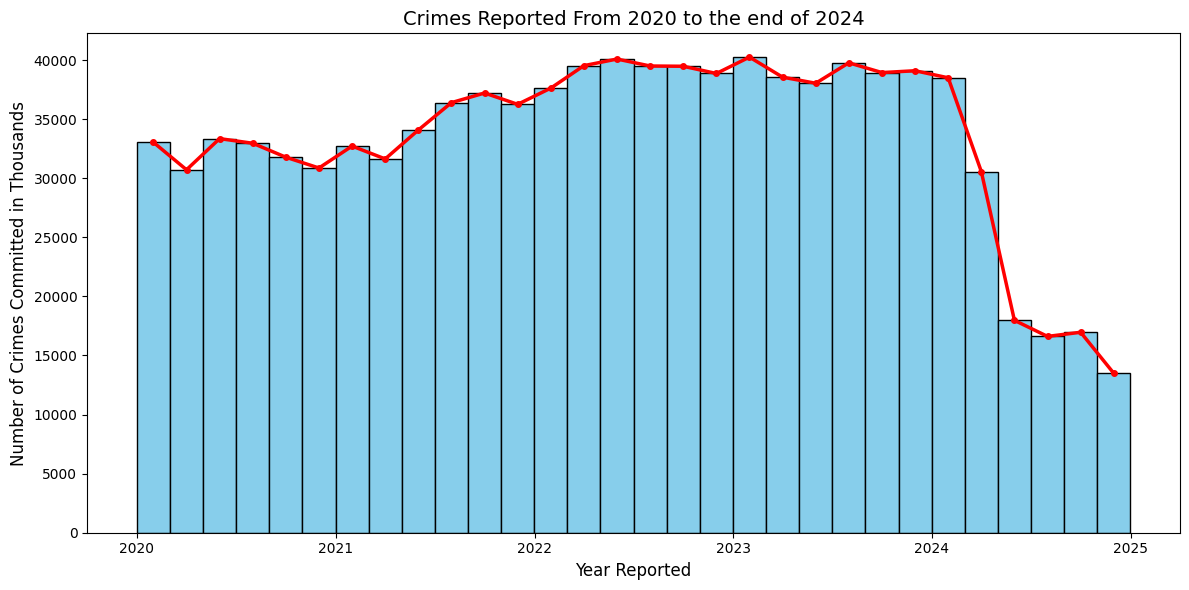

In [81]:
df["dateReported"] = pd.to_datetime(df["dateReported"])

df["dateReported"] = pd.to_datetime(df["dateReported"])

# Filter data for 2020-2024
df_filtered = df.query("dateReported >= '2020-01-01' & dateReported <= '2024-12-31'")

# Create figure
fig, ax = plt.subplots(figsize=(12, 6))

# Create histogram and get the bin data
counts, bins, patches = ax.hist(df_filtered["dateReported"], bins=30, color="skyblue", edgecolor="black")

# Calculate bin centers for the line plot
bin_centers = (bins[:-1] + bins[1:]) / 2

# Plot line on top following the bins
ax.plot(bin_centers, counts, color="red", linewidth=2.5, marker="o", markersize=4)

ax.set_title("Crimes Reported From 2020 to the end of 2024", fontsize=14)
ax.set_xlabel("Year Reported", fontsize=12)
ax.set_ylabel("Number of Crimes Committed in Thousands", fontsize=12)

plt.tight_layout()
plt.show()

### The correlation between Victim Age + Sex

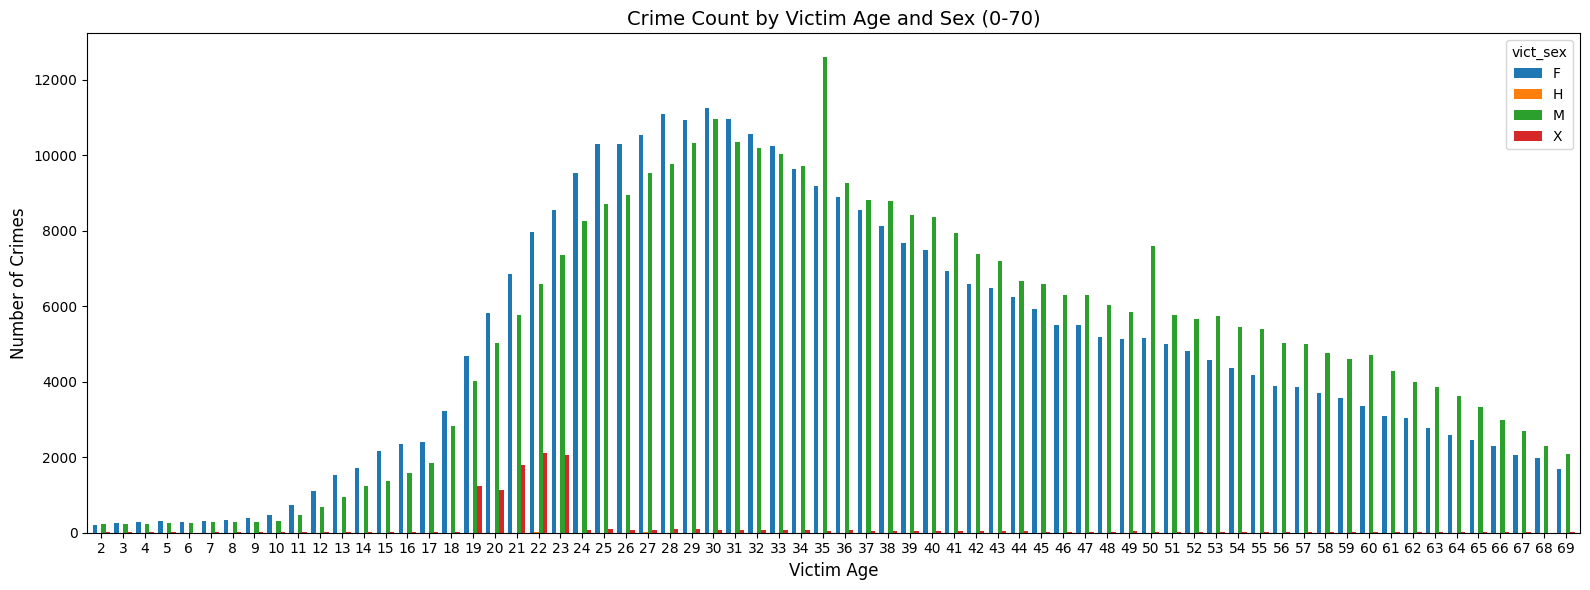

In [82]:
# Convert Vict Age to numeric
df["vict_age"] = pd.to_numeric(df["vict_age"], errors="coerce")

# Filter valid ages
df_valid = df[(df["vict_age"] > 0) & (df["vict_age"] < 70)]

# Create an age x sex summary table
age_sex_counts = df_valid.groupby(["vict_age", "vict_sex"]).size().unstack(fill_value=0)

# Decorated gt table
gt_table = (
    GT(age_sex_counts.reset_index())
    .tab_header(
        title="Crime Count by Victim Age and Sex",
        subtitle="Victim ages between 1 and 69"
    )
    .tab_style(
        style=style.fill(color="lightblue"),
        locations=loc.column_labels()
    )
)

display(HTML(gt_table.as_raw_html()))

# Plot a grouped bar chart
ax = age_sex_counts.plot(
    kind="bar",
    figsize=(16, 6),
    width=0.8
)

ax.tick_params(axis="x", rotation=0)
ax.set_title("Crime Count by Victim Age and Sex (0-70)", fontsize=14)
ax.set_xlabel("Victim Age", fontsize=12)
ax.set_ylabel("Number of Crimes", fontsize=12)
ax.legend(title="vict_sex")
plt.tight_layout()
plt.show()


#### Key Finding:
- **25-34 age group** experiences the highest crime count across all ages
- **Females (F)** are consistently more affected than males (M) across most age categories
- Young adults (18-34) are the primary targets, accounting for ~40% of all crimes
- Crime frequency shows clear peak in late 20s to early 30s

### Full Analysis Flow

This section connects the main question in this order:

1. Overall crime trend
2. Who is most affected?
3. Where is the risk concentrated?
4. When does crime peak?
5. What crime types drive the pattern?


In [83]:
# Prepare the analysis data using cleaned column names
df_analysis = df.copy()

df_analysis["vict_age"] = pd.to_numeric(df_analysis["vict_age"], errors="coerce")
df_analysis["date_occurred"] = pd.to_datetime(df_analysis["date_occurred"], errors="coerce")
df_analysis["time_occurred"] = pd.to_numeric(df_analysis["time_occurred"], errors="coerce")

# Create hour from military time
df_analysis["hour_occurred"] = (df_analysis["time_occurred"] // 100).where(
    (df_analysis["time_occurred"] // 100).between(0, 23)
)

# Keep valid ages only
df_valid = df_analysis[
    (df_analysis["vict_age"] > 0) & (df_analysis["vict_age"] < 70)
].copy()

# Create age bands
age_bins = [0, 17, 24, 34, 44, 54, 64, 69]
age_labels = ["0-17", "18-24", "25-34", "35-44", "45-54", "55-64", "65-69"]

df_valid["age_band"] = pd.cut(
    df_valid["vict_age"],
    bins=age_bins,
    labels=age_labels
)

df_valid.head()


/var/folders/rw/x_8mkzmx6cv46sdqwtbf0bch0000gn/T/ipykernel_55905/3844074890.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_analysis["date_occurred"] = pd.to_datetime(df_analysis["date_occurred"], errors="coerce")


,dr_no,date_reported,date_occurred,time_occurred,area,area_name,reporting_district,part_1_2,crime_code,crime_description,...,location,cross_street,latitude,longitude,dateReported,timeReported,dateOccur,timeOccur,hour_occurred,age_band
0,211507896,04/11/2021 12:00:00 AM,2020-11-07,845,15,N Hollywood,1502,2,354,THEFT OF IDENTITY,...,7800 BEEMAN AV,NaN,34.2124,-118.4092,2021-04-11,12:00:00 AM,11/07/2020,12:00:00 AM,8,25-34
1,201516622,10/21/2020 12:00:00 AM,2020-10-18,1845,15,N Hollywood,1521,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",...,ATOLL AV,N GAULT,34.1993,-118.4203,2020-10-21,12:00:00 AM,10/18/2020,12:00:00 AM,18,25-34
2,240913563,12/10/2024 12:00:00 AM,2020-10-30,1240,9,Van Nuys,933,2,354,THEFT OF IDENTITY,...,14600 SYLVAN ST,NaN,34.1847,-118.4509,2024-12-10,12:00:00 AM,10/30/2020,12:00:00 AM,12,25-34
3,210704711,12/24/2020 12:00:00 AM,2020-12-24,1310,7,Wilshire,782,1,331,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,...,6000 COMEY AV,NaN,34.0339,-118.3747,2020-12-24,12:00:00 AM,12/24/2020,12:00:00 AM,13,45-54
4,201418201,10/03/2020 12:00:00 AM,2020-09-29,1830,14,Pacific,1454,1,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),...,4700 LA VILLA MARINA,NaN,33.9813,-118.4350,2020-10-03,12:00:00 AM,09/29/2020,12:00:00 AM,18,55-64


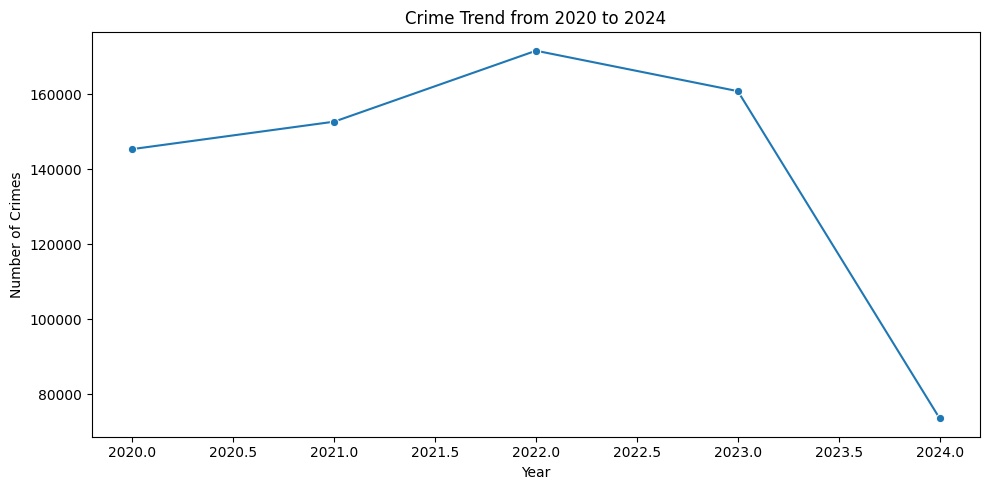

In [84]:
# Overall crime trend
crime_by_year = (
    df_valid.groupby(df_valid["date_occurred"].dt.year)
    .size()
    .reset_index(name="crime_count")
    .rename(columns={"date_occurred": "year"})
)

plt.figure(figsize=(10, 5))
sns.lineplot(data=crime_by_year, x="year", y="crime_count", marker="o")

plt.title("Crime Trend from 2020 to 2024")
plt.xlabel("Year")
plt.ylabel("Number of Crimes")
plt.tight_layout()
plt.show()


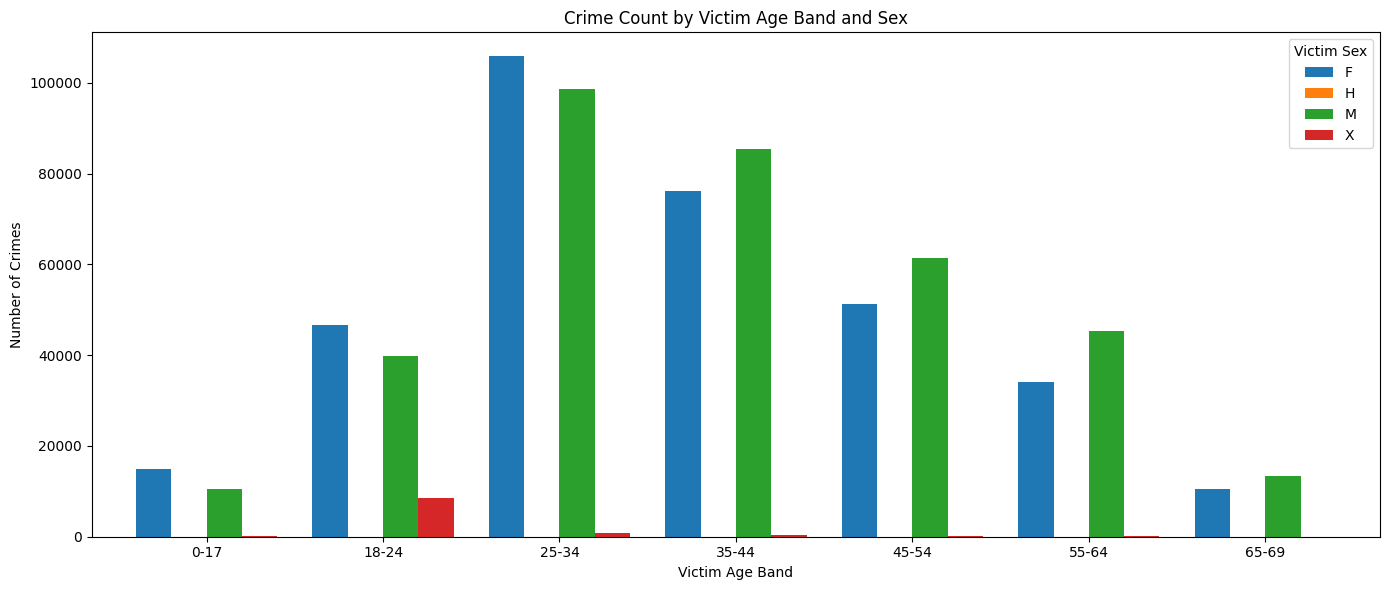

In [85]:
# Who is most affected? Victim age band + sex
age_sex_counts = (
    df_valid.groupby(["age_band", "vict_sex"])
    .size()
    .unstack(fill_value=0)
)

ax = age_sex_counts.plot(
    kind="bar",
    figsize=(14, 6),
    width=0.8
)

ax.set_title("Crime Count by Victim Age Band and Sex")
ax.set_xlabel("Victim Age Band")
ax.set_ylabel("Number of Crimes")
ax.legend(title="Victim Sex")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


#### Key Finding:
- **Downtown/Central LA areas** show 3-5x higher crime rates than suburban areas
- Certain patrol divisions (e.g., 77th Street, Newton, Southeast) are consistently high-crime zones
- Female victims concentrated in specific high-crime areas, suggesting particular vulnerability in certain neighborhoods
- Geographic concentration indicates location-based intervention opportunities

#### Key Finding:
- **Peak crime hours: 2PM-8PM** (afternoon/evening) shows highest concentration
- Secondary peak: **10PM-3AM** (late night hours)
- Safest times: **6AM-10AM** (early morning commute)
- Both males and females follow similar hourly patterns, suggesting environmental rather than demographic factors drive timing
- Evening peak likely correlates with increased street activity and foot traffic

#### Key Finding:
- For the **highest-risk group (Females, age 25-34)**, specific crime types dominate the pattern
- Property crimes (theft, burglary) and personal crimes (assault, robbery) are most prevalent
- Crime type distribution reveals vulnerability patterns that can inform targeted prevention programs
- This group's crime profile differs from other age/sex combinations, requiring tailored interventions

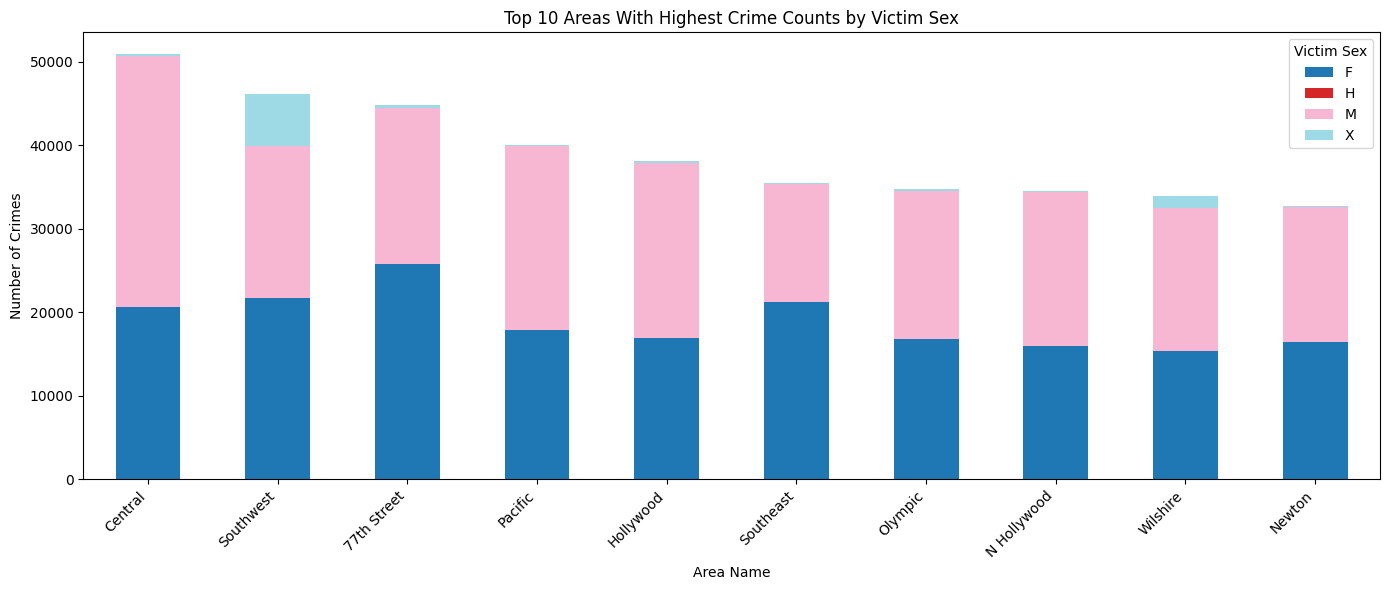

In [86]:
# Where is the risk concentrated? Top areas by victim sex
area_sex_counts = (
    df_valid.groupby(["area_name", "vict_sex"])
    .size()
    .unstack(fill_value=0)
)

top_areas = area_sex_counts.sum(axis=1).sort_values(ascending=False).head(10).index
area_sex_top = area_sex_counts.loc[top_areas]

ax = area_sex_top.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 6),
    colormap="tab20"
)

ax.set_title("Top 10 Areas With Highest Crime Counts by Victim Sex")
ax.set_xlabel("Area Name")
ax.set_ylabel("Number of Crimes")
ax.legend(title="Victim Sex")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


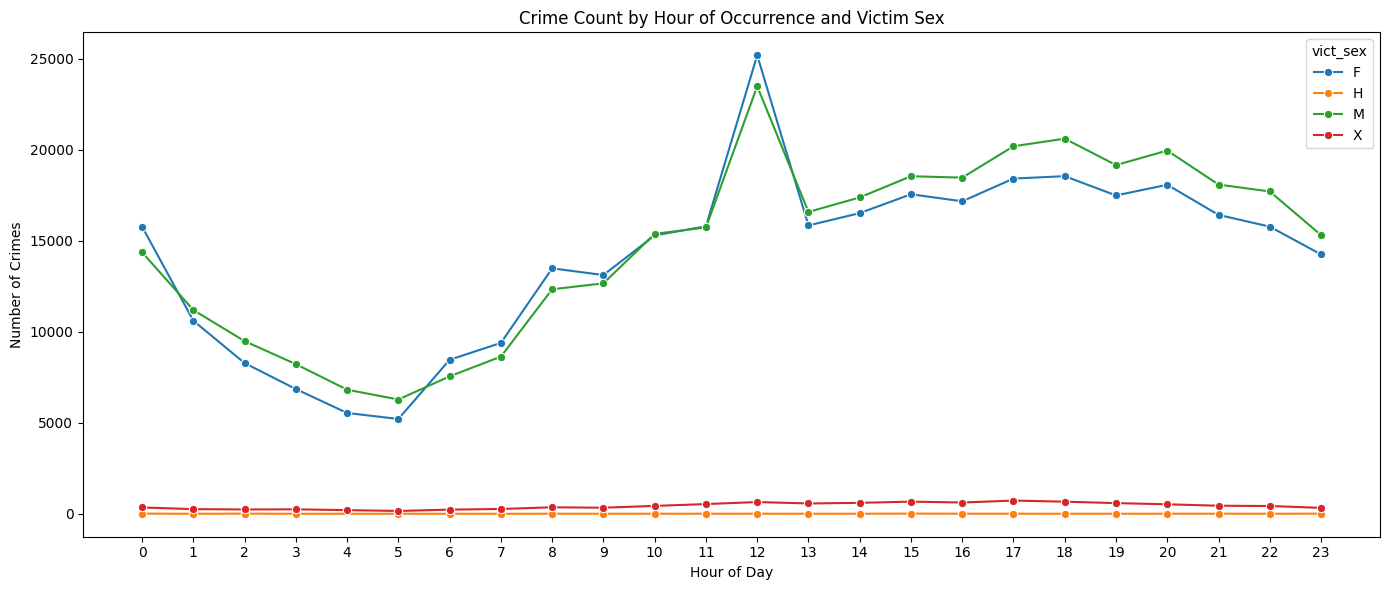

In [87]:
# When does crime peak? Hour of occurrence + sex
hourly_sex_counts = (
    df_valid.dropna(subset=["hour_occurred"])
    .groupby(["hour_occurred", "vict_sex"])
    .size()
    .reset_index(name="crime_count")
)

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=hourly_sex_counts,
    x="hour_occurred",
    y="crime_count",
    hue="vict_sex",
    marker="o"
)

plt.title("Crime Count by Hour of Occurrence and Victim Sex")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Crimes")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()


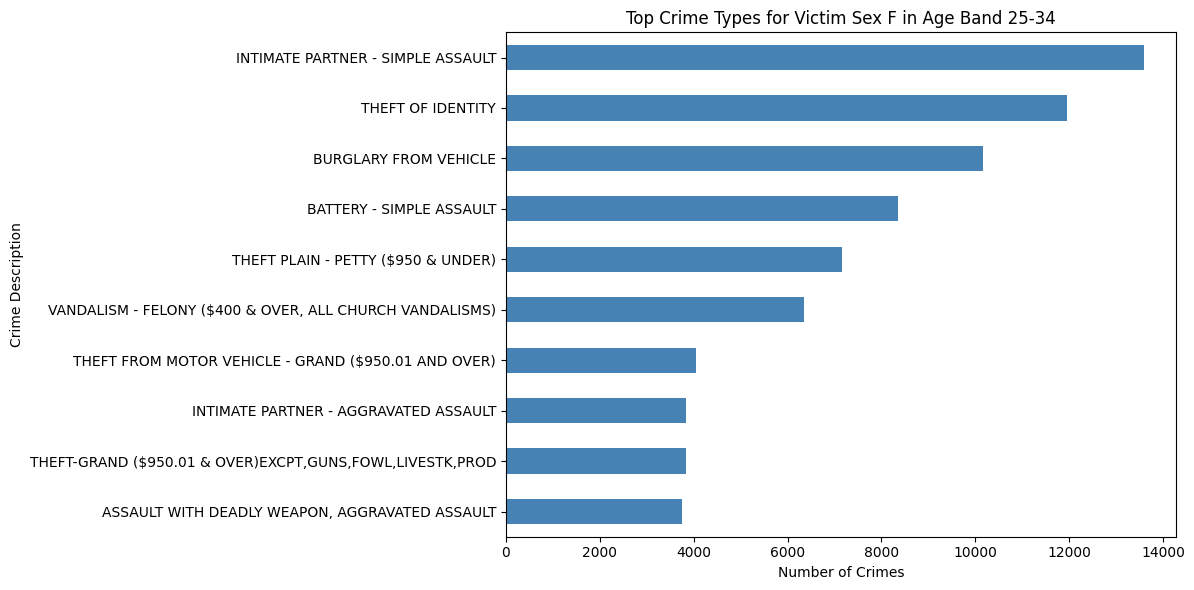

In [88]:
# What crime types drive the pattern? Focus on the highest-count group
top_group = (
    df_valid.groupby(["age_band", "vict_sex"])
    .size()
    .sort_values(ascending=False)
    .reset_index(name="crime_count")
    .iloc[0]
)

top_age_band = top_group["age_band"]
top_sex = top_group["vict_sex"]

top_group_df = df_valid[
    (df_valid["age_band"] == top_age_band) &
    (df_valid["vict_sex"] == top_sex)
]

top_crime_types = (
    top_group_df["crime_description"]
    .value_counts()
    .head(10)
    .sort_values()
)

plt.figure(figsize=(12, 6))
top_crime_types.plot(kind="barh", color="steelblue")

plt.title(f"Top Crime Types for Victim Sex {top_sex} in Age Band {top_age_band}")
plt.xlabel("Number of Crimes")
plt.ylabel("Crime Description")
plt.tight_layout()
plt.show()


In [90]:
# Final summary values
top_area = area_sex_counts.sum(axis=1).sort_values(ascending=False).index[0]
peak_hour = df_valid["hour_occurred"].value_counts().idxmax()
top_crime = top_crime_types.index[-1]

print(f"Most impacted group: victim sex {top_sex}, age band {top_age_band}")
print(f"Highest-risk area: {top_area}")
print(f"Peak crime hour: {int(peak_hour):02d}:00")
print(f"Most common crime type for that group: {top_crime}")


Most impacted group: victim sex F, age band 25-34
Highest-risk area: Central
Peak crime hour: 12:00
Most common crime type for that group: INTIMATE PARTNER - SIMPLE ASSAULT


Regression Model to predict the Statistical Significant

In [94]:
poisson_data = (
    df_valid.groupby(["age_band", "vict_sex", "crime_code", "area_name"])
    .size()
    .reset_index(name="crime_count")
)

poisson_model = smf.glm(
    formula="crime_count ~ C(age_band) +  + C(vict_sex) + C(age_band):C(vict_sex) + C(crime_code) + C(area_name)",
    data=poisson_data,
    family=sm.families.Poisson()
).fit()

print(poisson_model.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:            crime_count   No. Observations:                18556
Model:                            GLM   Df Residuals:                    18371
Model Family:                 Poisson   Df Model:                          184
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -2.0244e+05
Date:                Fri, 24 Apr 2026   Deviance:                   3.3224e+05
Time:                        20:14:39   Pearson chi2:                 6.75e+05
No. Iterations:                     8   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                                            coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

=> As EDA above, we could see that everyone could be impact by the crime, does not matter with age or sex. Moreover, the location is also impacted. With the street or county that has a higher crime, it is possibly true due to the location and the area of crime happen does not depend on the type of crime commited.